In [1]:
# Parameters
name      = ""
fits_path = ""

In [2]:
# Parameters
name = "LVM-30Dor-6583_M2"
fits_path = "fits_ready/LVM-30Dor-6583_M2.fits"


In [3]:
import time
start_time = time.time()

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
import lmfit
from lmfit.model import save_modelresult


In [5]:
# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
#import strucfunc                   
import bfunc
import bplot
from reduced_chi2 import make_weights, tune_relative_uncertainty

In [6]:
with fits.open("fits_ready/" + name + ".fits") as hdul:
    hdr = hdul[0].header

#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
#noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [7]:
hdul.info()

Filename: fits_ready/LVM-30Dor-6583_M2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      


In [8]:
pc_per_arcsec = pc
data = name

In [9]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_in = t.to_pandas()


B        = np.array(data_in['Unweighted B(r)'])#[mask]
r        = np.array(10 ** np.array(data_in['log10 r']))#[mask]

# Fit and Confidence intervals

## Non-Linear Least-Squares Fitting

In [10]:
# Merging point

K = 10
r[K] = np.mean(r[: K + 1])
B[K] = np.mean(B[: K + 1])
r = r[K:]
B = B[K:]

In [11]:
# Define some scales for turning points in sf

r_local_peak = 2.5
r_local_minimum = 4.5

In [12]:
# Weights

#relative_uncertainty = 0.035
#weights = 1.0 / (relative_uncertainty * B)
#large_scale = r > 0.10 * box_size
#weights[large_scale] /= 2.0
#weights[:3] /= 2.0

#to_fit = r <= 0.15 * box_size
#to_fit = ~large_scale

In [13]:
# Weight configuration

weight_config = dict(
    large_scale_limit=0.25,
    fit_limit=0.35,
    large_scale_factor=2.0,
    first_points_factor=2.0,
    n_first_points=3,
)

initial_relative_uncertainty = 0.05

In [14]:
to_fit = r <= weight_config["fit_limit"] * box_size
large_scale = r > weight_config["large_scale_limit"] * box_size

In [15]:
model = lmfit.Model(bfunc.bfunc03s)
model.param_names

['r0', 'sig2', 'm', 's0', 'noise']

In [16]:
# Correlation length between 1/10 and 2 x box_size
model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=2 * box_size)

# sig2 between 1/4 and 2 x max value of B(r)
#model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2 * B.max())
model.set_param_hint("sig2", 
                     value = 0.50 * B[to_fit].max(), 
                     min   = 0.25 * B[to_fit].max(), 
                     max   = 2.00 * B[to_fit].max()) 

# m between 1/2 and 5/3
model.set_param_hint("m", value=1.0, min=0.5, max=2.0)

# Seeing RMS between 0.1 and 1.5 arcsec
model.set_param_hint(
    "s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec
)

# Noise cannot be much larger than smallest B(r)
model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())

# box_size is fixed
# model.set_param_hint("box_size", value=box_size, vary=False)

In [17]:
pd.DataFrame(model.param_hints)

,r0,sig2,m,s0,noise
value,33.011721,13.341558,1.0,0.121203,2.804510
min,3.301172,6.670779,0.5,0.024241,0.000000
max,660.234413,53.366231,2.0,0.363610,16.827061


In [18]:
#result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

In [19]:
def fit_function(r_fit, B_fit, weights_fit):
    return model.fit(
        B_fit,
        weights=weights_fit,
        r=r_fit,
    )


result, relative_uncertainty, history = tune_relative_uncertainty(
    fit_function,
    r,
    B,
    box_size,
    initial_relative_uncertainty=initial_relative_uncertainty,
    target_redchi_min=0.5,
    target_redchi_max=1.0,
    step_factor=1.15,
    **weight_config,
)

iter 00: relative_uncertainty = 0.05000, redchi = 0.2502


iter 01: relative_uncertainty = 0.04348, redchi = 0.3310


iter 02: relative_uncertainty = 0.03781, redchi = 0.4375


iter 03: relative_uncertainty = 0.03288, redchi = 0.5789
Accepted relative_uncertainty.


In [20]:
weights_fit, to_fit, weights, large_scale = make_weights(
    r,
    B,
    box_size,
    relative_uncertainty=relative_uncertainty,
    **weight_config,
)

print("Accepted relative_uncertainty:", relative_uncertainty)
print("Final reduced chi-square:", result.redchi)

Accepted relative_uncertainty: 0.032875811621599416
Final reduced chi-square: 0.5788935975571484


In [21]:
result

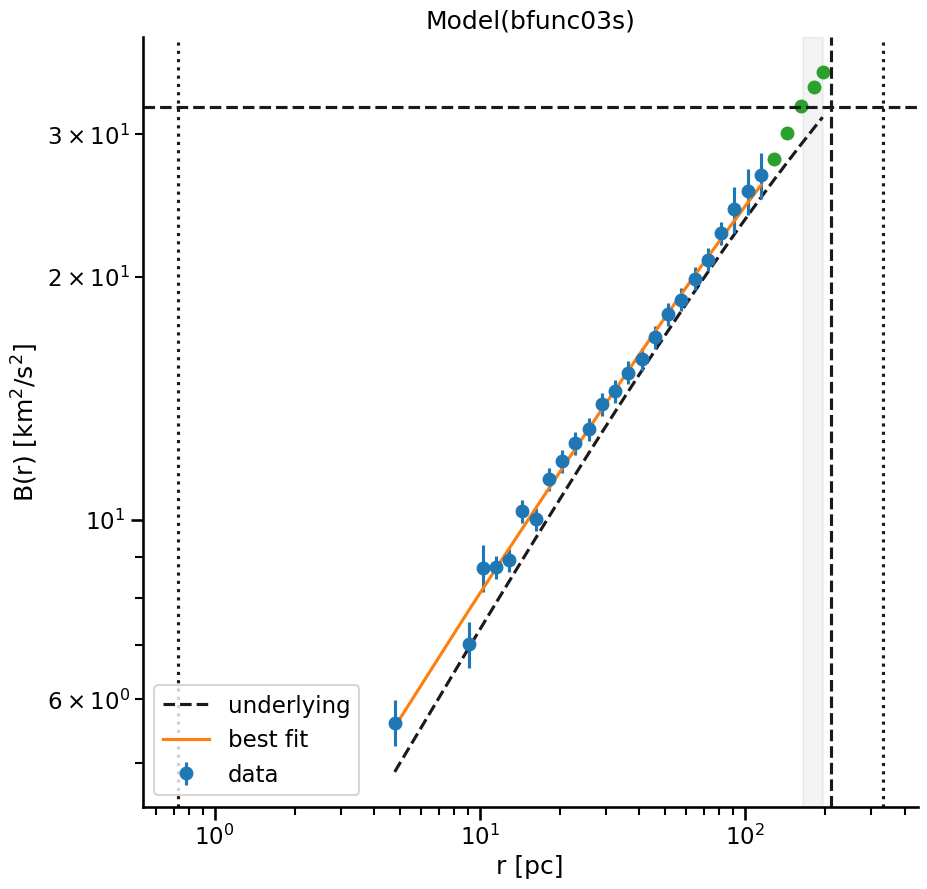

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the underlying model without instrumental effects
Bu = bfunc.bfunc00s(
    r, result.params["r0"].value, result.params["sig2"].value, result.params["m"].value
)
ax.plot(r, Bu, color="k", linestyle="dashed", label="underlying")

# Plot the fit results
result.plot_fit(ax=ax)

# Add in the points not included in fit
ax.plot(r[~to_fit], B[~to_fit], "o")

# Dotted lines for 2 x rms seeing and for box size
ax.axvline(2 * result.params["s0"].value, color="k", linestyle="dotted")
ax.axvline(box_size, color="k", linestyle="dotted")

# Dashed lines for best-fit r0 and sig2
ax.axvline(result.params["r0"].value, color="k", linestyle="dashed")
ax.axhline(result.params["sig2"].value, color="k", linestyle="dashed")

# Gray box to indicate the large scale values that are excluded from the fit
ax.axvspan(box_size / 2, r[-1], color="k", alpha=0.05, zorder=-1)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="r [pc]",
    ylabel=r"B(r) [km$^{2}$/s$^{2}$]",
)
sns.despine()

## emcee

In [23]:
emcee_kws = dict(
    steps=35000, burn=1000, thin=50, is_weighted=True, progress=False, workers=1
)
emcee_params = result.params.copy()
# emcee_params.add('__lnsigma', value=np.log(0.1), min=np.log(0.001), max=np.log(2.0))

In [24]:
result_emcee = model.fit(
    data=B[to_fit],
    r=r[to_fit],
    weights=weights[to_fit],
    params=emcee_params,
    method="emcee",
    nan_policy="omit",
    fit_kws=emcee_kws,
)

The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 700;
tau: [ 948.18956346 1054.81914701  854.16435103  245.03890153  372.57612649]


In [25]:
result_emcee

Text(0, 0.5, 'acceptance fraction')

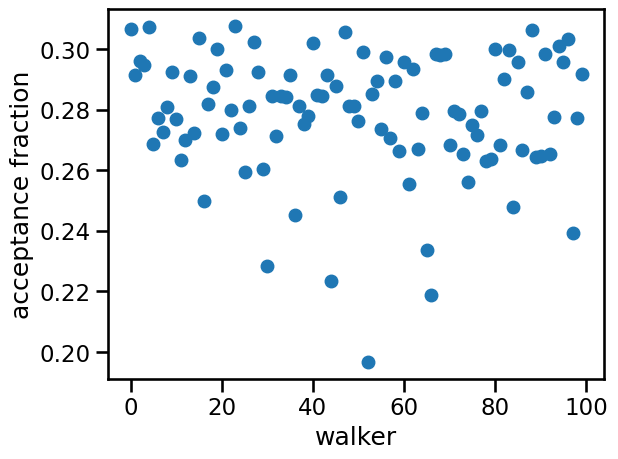

In [26]:
plt.plot(result_emcee.acceptance_fraction, "o")
plt.xlabel("walker")
plt.ylabel("acceptance fraction")



In [27]:
if hasattr(result_emcee, "acor"):
    print("Autocorrelation time for the parameters:")
    print("----------------------------------------")
    for i, p in enumerate(result_emcee.params):
        try:
            print(f"{p} = {result_emcee.acor[i]:.3f}")
        except IndexError:
            pass

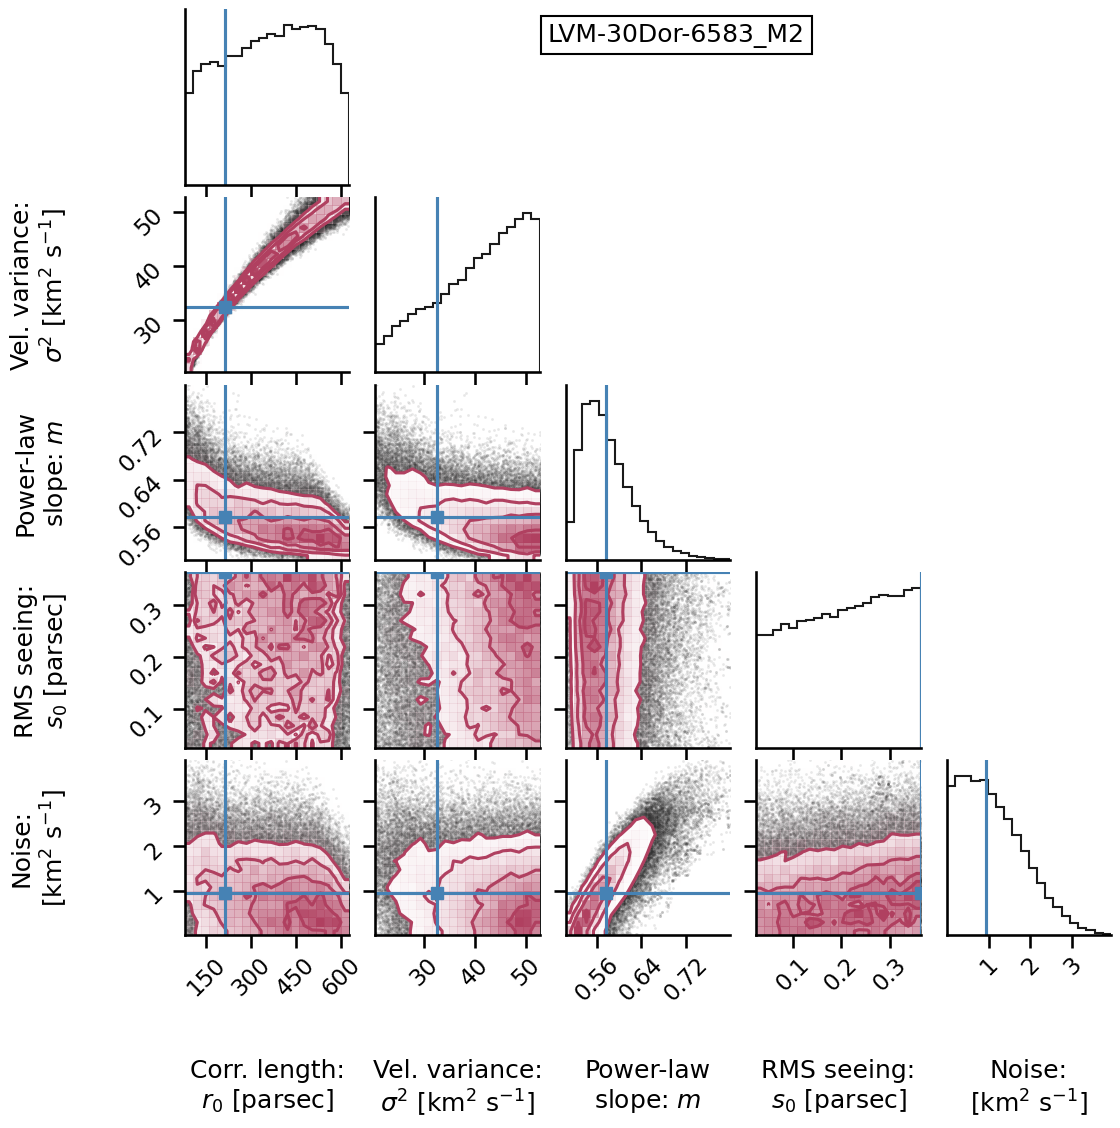

In [28]:
bplot.corner_plot(
    result_emcee, result, name, data, data_ranges=[0.95, 0.95, 0.995, 0.999, 0.999]
)

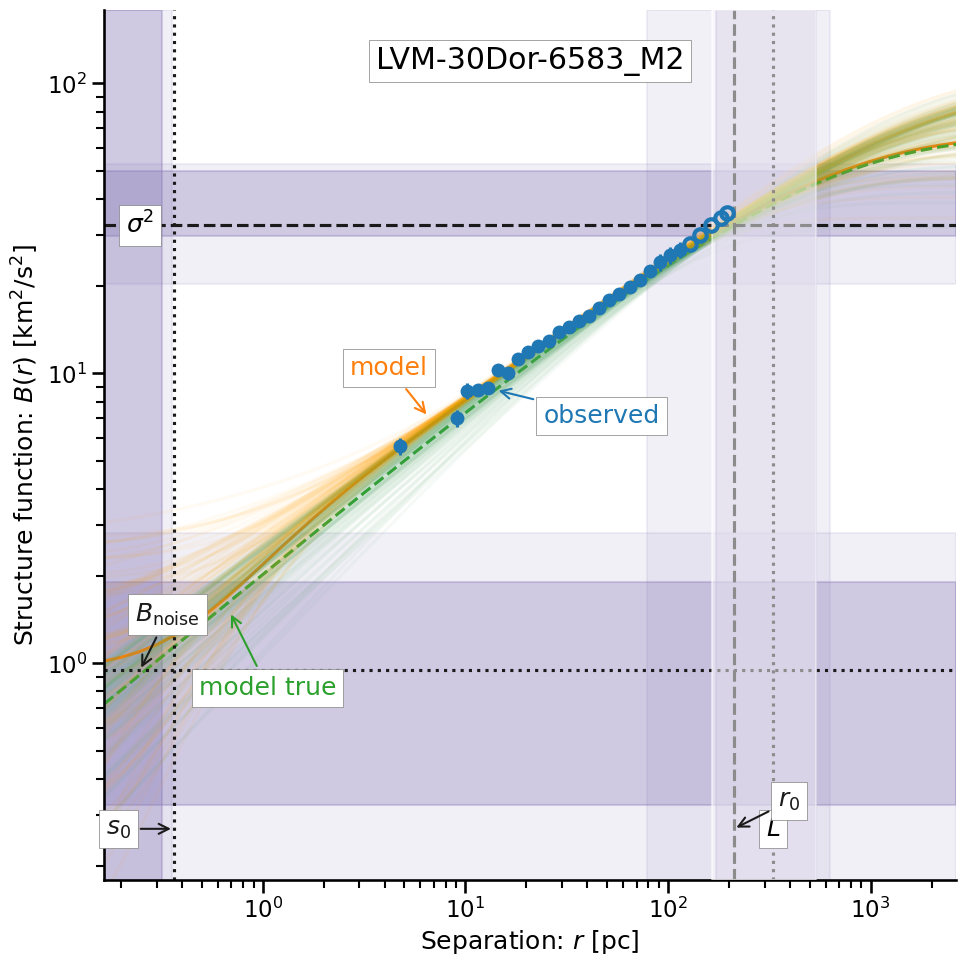

In [29]:
bplot.STYLE["data label element"] = 4
bplot.STYLE["model label element"] = 0
bplot.STYLE["model label offset"] = (-60, 40)
bplot.STYLE["true model label element"] = 7
bplot.STYLE["true model label offset"] = (30, -60)
bplot.strucfunc_plot(
    result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
)

In [30]:
LM = {
    'sig2': [result.params['sig2'].value,result.params['sig2'].stderr],
    'r0': [result.params['r0'].value,result.params['r0'].stderr],
    'm' : [result.params['m'].value,result.params['m'].stderr],
    's0': [result.params['s0'].value,result.params['s0'].stderr],
    'noise' : [result.params['noise'].value,result.params['noise'].stderr]
}

In [31]:
MCMC = {
    'sig2': [result_emcee.params['sig2'].value,result_emcee.params['sig2'].stderr],
    'r0': [result_emcee.params['r0'].value,result_emcee.params['r0'].stderr],
    'm' : [result_emcee.params['m'].value,result_emcee.params['m'].stderr],
    's0': [result_emcee.params['s0'].value,result_emcee.params['s0'].stderr],
    'noise' : [result_emcee.params['noise'].value,result_emcee.params['noise'].stderr]
}

In [32]:
sig2s2 = np.percentile(result_emcee.flatchain['sig2'],[2.5, 97.5])
r0s2 = np.percentile(result_emcee.flatchain['r0'],[2.5, 97.5])
ms2 = np.percentile(result_emcee.flatchain['m'],[2.5, 97.5])
s0s2 = np.percentile(result_emcee.flatchain['s0'],[2.5, 97.5])
b0s2 = np.percentile(result_emcee.flatchain['noise'],[2.5, 97.5])

In [33]:
sig2s2p = sig2s2[1]-result.params['sig2'].value
sig2s2m = result.params['sig2'].value-sig2s2[0]

r0s2p = r0s2[1]-result.params['r0'].value
r0s2m = result.params['r0'].value-r0s2[0]

ms2p = ms2[1]-result.params['m'].value
ms2m = result.params['m'].value-ms2[0]

s0s2p = s0s2[1]-result.params['s0'].value
s0s2m = result.params['s0'].value-s0s2[0]

b0s2p = b0s2[1]-result.params['noise'].value
b0s2m = result.params['noise'].value-b0s2[0]

In [34]:
# MCMC 1 sigma confidence interval

sig2s1 = np.percentile(result_emcee.flatchain['sig2'],[16, 85])
r0s1 = np.percentile(result_emcee.flatchain['r0'],[16, 85])
ms1 = np.percentile(result_emcee.flatchain['m'],[16, 85])
s0s1 = np.percentile(result_emcee.flatchain['s0'],[16, 85])
b0s1 = np.percentile(result_emcee.flatchain['noise'],[16, 85])

sig2s1p = sig2s1[1]-result.params['sig2'].value
sig2s1m = result.params['sig2'].value-sig2s1[0]

r0s1p = r0s1[1]-result.params['r0'].value
r0s1m = result.params['r0'].value-r0s1[0]

ms1p = ms1[1]-result.params['m'].value
ms1m = result.params['m'].value-ms1[0]

s0s1p = s0s1[1]-result.params['s0'].value
s0s1m = result.params['s0'].value-s0s1[0]

b0s1p = b0s1[1]-result.params['noise'].value
b0s1m = result.params['noise'].value-b0s1[0]

In [35]:
#  LM + MCMC 2 sigma

results_2sig = {
    'sig2': [result.params['sig2'].value,sig2s2p,sig2s2m],
    'r0': [result.params['r0'].value,r0s2p,r0s2m],
    'm' : [result.params['m'].value,ms2p,ms2m],
    's0': [result.params['s0'].value,s0s2p,s0s2m],
    'noise' : [result.params['noise'].value,b0s2p,b0s2m] 
    
}

results_2sig

{'sig2': [32.45061166439115, 20.32778488221031, 12.132939284131826],
 'r0': [211.35197032402297, 416.0619752869095, 132.8553794903809],
 'm': [0.5761672226490732, 0.12554541968046273, 0.060085974004481124],
 's0': [0.3634704561858166, -0.007210149577252578, 0.3288393154171925],
 'noise': [0.9476671404945761, 1.8760280415400064, 0.8953047330323726]}

In [36]:
#save_modelresult(result, "results_fit/" + name + "result_ideal.sav")
#save_modelresult(result_emcee, "results_fit/" + name + "result_emcee_ideal.sav")

In [37]:
df = pd.DataFrame(results_2sig)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ["_".join(map(str, col)).strip() for col in df.columns.to_flat_index()]
else:
    df.columns = [str(c) for c in df.columns]

df = df.reset_index(drop=True)

t = Table.from_pandas(df)
new_hdu = fits.BinTableHDU(t, name="PARAMETERS")

with fits.open(fits_path, memmap=False) as hdul:
    hdus = [h.copy() for h in hdul]

# FITS EXTNAMEs are effectively case-insensitive; astropy reports them uppercase.
target = "PARAMETERS"
idxs = [i for i, h in enumerate(hdus) if h.name.upper() == target]

if idxs:
    i0 = idxs[0]
    # Optional: preserve existing header cards (metadata) from old PARAMETERS
    old_hdr = hdus[i0].header.copy()
    hdus[i0] = new_hdu
    # Keep old metadata, then ensure EXTNAME stays correct
    hdus[i0].header.update(old_hdr)
    hdus[i0].name = target
    # Remove any additional duplicates if they exist
    for j in reversed(idxs[1:]):
        del hdus[j]
else:
    # If it doesn't exist, add it
    hdus.append(new_hdu)

fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [38]:
# Test import

from astropy.table import Table
t = Table.read(fits_path, hdu="PARAMETERS")
df_loaded = t.to_pandas()
df_loaded

,sig2,r0,m,s0,noise
0,32.450612,211.351970,0.576167,0.363470,0.947667
1,20.327785,416.061975,0.125545,-0.007210,1.876028
2,12.132939,132.855379,0.060086,0.328839,0.895305


In [39]:
with fits.open(fits_path) as hdul:
    hdul.info()

Filename: fits_ready/LVM-30Dor-6583_M2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      
  1  LVM-30DOR-6583_M2    1 BinTableHDU     23   3725R x 7C   [D, D, D, D, D, D, D]   
  2  TABLE         1 BinTableHDU     19   39R x 5C   [D, D, D, D, D]   
  3  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   


In [40]:
print("--- %s seconds ---" % (time.time() - start_time))

--- 126.30398321151733 seconds ---
